In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_complete = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Completed operations.csv",
    sep=";"
)
df_cancelled = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv",
    sep=";"
)
# Convert to datetime
df_complete['Dato'] = pd.to_datetime(df_complete['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_cancelled['Dato og tid'] = pd.to_datetime(df_cancelled['Dato og tid'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete = df_complete.rename(columns={'Dato': 'Dato_complete'})
df_cancelled = df_cancelled.rename(columns={'Dato og tid': 'Dato_cancelled'})

/var/folders/hs/9s0b5rgj539chsrz2hkbmzrr0000gn/T/ipykernel_54355/63544467.py:1: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv(


In [17]:
df_cancelled['Ombooket'] == 'Ja'

0      False
1      False
2      False
3      False
4      False
       ...  
570    False
571    False
572     True
573    False
574    False
Name: Ombooket, Length: 575, dtype: bool

In [3]:
common_ids = set(df_complete['Case-ID Anonymous']).intersection(df_cancelled['Case-ID Anonymous'])
df_complete_common = df_complete[df_complete['Case-ID Anonymous'].isin(common_ids)]
df_cancelled_common = df_cancelled[df_cancelled['Case-ID Anonymous'].isin(common_ids)]
len(common_ids), len(df_complete_common), len(df_cancelled_common)

(378, 405, 426)

In [4]:
df_complete_common_sort = df_complete_common.sort_values(by='Case-ID Anonymous')
df_cancelled_common_sort = df_cancelled_common.sort_values(by='Case-ID Anonymous')

In [5]:
df_complete_common_sort

,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Dato_complete,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,Ressource.Olympus Exera II (anæstesisøjle),Ressource.Sonostar,Ressource.COP3589 A O bøjejern rekonstruktionsskinner,Ressource.BMAC-centrifuge,Ressource.Benchbord,Ressource.Diodelaser næse,Ressource.Øre optik 30°,Ressource.Endoskop,Ressource.Flexcystoskop,Ressource.Kasette
48818,332,1,Børnekirurgi,JMC 02,620,Nej,2024-01-03,"2023-12-22 07:30:00,000","2024-01-03 08:05:00,000","2024-01-03 07:45:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46823,7574,71,Kirurgi,CKO LEJE 01,618,Ja,2024-01-03,"2024-01-02 12:55:00,000","2024-01-03 22:05:00,000",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45450,7868,71,Kirurgi,CKO LEJE 03,618,Ja,2024-01-05,"2024-01-02 12:55:00,000","2024-01-05 20:50:00,000","2024-01-05 20:51:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41508,8054,71,Medicinsk gastroenterologi,CKO RTG LEJE U/A,618,Ja,2024-01-07,"2024-01-02 12:55:00,000","2024-01-07 14:10:00,000",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87793,11424,7,Hæmatologi-Onkologi pædiatrisk,JMC 05,620,Nej,2024-02-12,"2024-02-07 13:46:00,000","2024-02-12 10:30:00,000","2024-02-12 10:44:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98782,120678,11,Pædiatri,JMC 04,620,Ja,2025-12-23,"2025-12-23 13:41:00,000","2025-12-23 15:45:00,000","2025-12-23 15:30:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16609,120698,71,Thoraxkirurgi,RT LEJE 15,622,Ja,2025-12-24,"2025-12-23 13:59:00,000","2025-12-24 11:05:00,000","2025-12-24 15:09:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8570,120793,40,Kirurgi,CKO RTG LEJE 12,618,Ja,2025-12-29,"2025-12-29 07:53:00,000","2025-12-29 11:00:00,000","2025-12-29 10:00:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48119,120801,58,Thoraxkirurgi,RT ENDO 3151,622,Nej,2025-12-30,"2025-12-22 21:31:00,000","2025-12-30 08:15:00,000","2025-12-30 08:13:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_cancelled_common_sort

,Case-ID Anonymous,Dato_cancelled,Primær procedure - Tekst,Aflyst efter operationsprogrammet er afsluttet?,Aflyst på dagen for operationen?,Aflysningsårsag,Forventet varighed (min.),Ombooket,Stue,Operationsgang ID
218,332,2024-01-03 08:05:00,LAPAROSKOPI / LAPAROTOMI,Nej,Nej,NaN,315,Nej,JMC 02,620.0
0,7574,2024-01-03 22:05:00,GASTROSKOPI,Nej,Nej,NaN,93,Nej,CKO LEJE 01,618.0
1,7868,2024-01-05 20:50:00,KOLOSKOPI,Nej,Nej,NaN,87,Nej,CKO LEJE 03,618.0
467,7868,2024-01-06 09:00:00,KOLOSKOPI,Ja,Nej,Aflysning som ikke kan klassificeres,87,Ja,CKO LEJE 03,618.0
2,8054,2024-01-07 14:10:00,INVR EMBOLISERING,Nej,Nej,NaN,132,Nej,CKO RTG LEJE U/A,618.0
...,...,...,...,...,...,...,...,...,...,...
386,120678,2025-12-23 15:45:00,LUMBALPUNKTUR,Nej,Nej,NaN,57,Nej,JMC 04,620.0
387,120698,2025-12-24 11:05:00,ESOPHAGOSKOPI,Nej,Nej,NaN,67,Nej,RT LEJE 15,622.0
204,120793,2025-12-29 11:00:00,INVR CHOLANGIOGRAFI,Nej,Nej,NaN,89,Nej,CKO RTG LEJE 12,618.0
388,120801,2025-12-30 08:15:00,BRONKOSKOPI - ARGON,Nej,Nej,NaN,55,Nej,RT ENDO 3151,622.0


In [7]:
df_complete_common['Case-ID Anonymous'].value_counts().head(), \
df_cancelled_common['Case-ID Anonymous'].value_counts().head()

(Case-ID Anonymous
 47845     4
 14892     3
 114181    3
 46493     2
 52643     2
 Name: count, dtype: int64,
 Case-ID Anonymous
 43086     5
 14892     3
 27146     3
 119281    2
 90959     2
 Name: count, dtype: int64)

In [8]:
sum(df_complete_common['Case-ID Anonymous'].value_counts()>1), \
sum(df_cancelled_common['Case-ID Anonymous'].value_counts()>1)

(23, 43)

In [9]:
df_complete.columns

Index(['Case-ID Anonymous', 'Patient Alder', 'Speciale', 'Stue',
       'Operationsgang ID', 'Akut case (J/N)', 'Dato_complete',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start',
       ...
       'Ressource.Olympus Exera II (anæstesisøjle)', 'Ressource.Sonostar',
       'Ressource.COP3589   A O bøjejern rekonstruktionsskinner',
       'Ressource.BMAC-centrifuge', 'Ressource.Benchbord',
       'Ressource.Diodelaser næse', 'Ressource.Øre optik 30°',
       'Ressource.Endoskop', 'Ressource.Flexcystoskop', 'Ressource.Kasette'],
      dtype='object', length=247)

In [10]:
complete_lookup = (
    df_complete[['Case-ID Anonymous', 'Patient Alder', 'Dato_complete', 'Akut case (J/N)']].drop_duplicates('Case-ID Anonymous')
    )

df = df_cancelled[['Case-ID Anonymous', 'Dato_cancelled']].drop_duplicates('Case-ID Anonymous')
df = df.merge(
    complete_lookup,
    on='Case-ID Anonymous',
    how='left',
)

df['Time difference'] = (
    df['Dato_cancelled'] -
    df['Dato_complete']
).dt.days

df = df.dropna()

In [11]:
df

,Case-ID Anonymous,Dato_cancelled,Patient Alder,Dato_complete,Akut case (J/N),Time difference
0,7574,2024-01-03 22:05:00,71.0,2024-01-03,Ja,0.0
1,7868,2024-01-05 20:50:00,71.0,2024-01-05,Ja,0.0
2,8054,2024-01-07 14:10:00,71.0,2024-01-07,Ja,0.0
3,11481,2024-01-26 11:00:00,53.0,2024-01-26,Ja,0.0
4,16394,2024-02-26 08:05:00,12.0,2024-02-26,Ja,0.0
...,...,...,...,...,...,...
385,120658,2025-12-23 13:14:00,69.0,2025-12-23,Ja,0.0
386,120678,2025-12-23 15:45:00,11.0,2025-12-23,Ja,0.0
387,120698,2025-12-24 11:05:00,71.0,2025-12-24,Ja,0.0
388,120801,2025-12-30 08:15:00,58.0,2025-12-30,Nej,0.0


In [12]:
df['Time difference'].sum()

0.0

In [111]:
sum(df['Akut case (J/N)'] == 'Nej')

76

In [112]:
df[df['Akut case (J/N)'] == 'Nej']

,Case-ID Anonymous,Dato_cancelled,Patient Alder,Dato_complete,Akut case (J/N),Time difference
15,29726,2024-05-29 13:15:00,33.0,2024-05-29,Nej,0.0
22,33530,2024-06-07 08:05:00,33.0,2024-06-07,Nej,0.0
23,33831,2024-06-10 12:20:00,26.0,2024-06-10,Nej,0.0
24,33993,2024-06-25 08:05:00,71.0,2024-06-25,Nej,0.0
27,35072,2024-06-17 12:30:00,73.0,2024-06-17,Nej,0.0
...,...,...,...,...,...,...
362,113022,2025-10-16 12:40:00,56.0,2025-10-16,Nej,0.0
367,114533,2025-10-31 13:55:00,17.0,2025-10-31,Nej,0.0
368,115275,2025-12-16 10:15:00,10.0,2025-12-16,Nej,0.0
369,115295,2025-11-11 12:00:00,17.0,2025-11-11,Nej,0.0


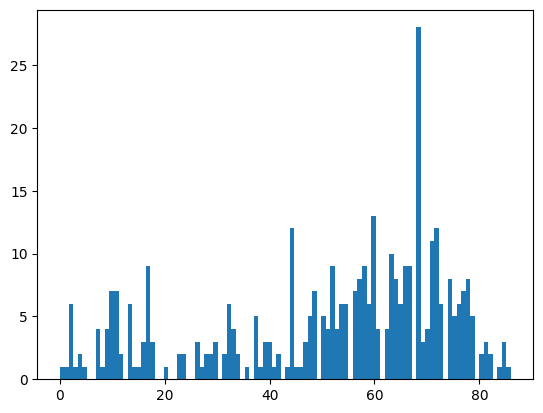

In [116]:
plt.hist(df['Patient Alder'], bins=100)
plt.show()

In [38]:
rebooked_ID = df_cancelled[df_cancelled['Ombooket'] == 'Ja']['Case-ID Anonymous']
both_ID = df['Case-ID Anonymous']
rebooked_not_common_ID = set(rebooked_ID) - set(both_ID)

In [44]:
common_ids = set(df_complete['Case-ID Anonymous']).intersection(df_cancelled['Case-ID Anonymous'])
df_cancelled_not_common = df_cancelled[~df_cancelled['Case-ID Anonymous'].isin(common_ids)]
print(df_cancelled_not_common[df_cancelled_not_common['Ombooket'] == 'Ja']['Dato_cancelled'])
print(len(df_cancelled_not_common[df_cancelled_not_common['Ombooket'] == 'Ja']['Dato_cancelled']))

519   2024-04-29 09:30:00
520   2024-04-30 12:00:00
527   2024-07-05 09:29:00
528   2024-07-15 09:00:00
529   2024-12-17 13:30:00
530   2024-12-20 10:30:00
532   2024-07-27 22:40:00
537   2024-08-27 12:55:00
541   2024-09-18 20:20:00
542   2024-09-19 16:35:00
545   2024-10-08 08:20:00
546   2024-10-25 10:57:00
551   2024-12-03 12:31:00
556   2025-04-09 08:55:00
557   2025-05-07 11:55:00
558   2025-05-19 12:02:00
564   2025-07-16 13:00:00
566   2025-07-28 14:00:00
567   2025-08-19 13:59:00
568   2025-08-20 13:57:00
572   2025-11-06 12:59:00
Name: Dato_cancelled, dtype: datetime64[ns]
21


In [62]:
df_cancelled_not_common[df_cancelled_not_common['Ombooket'] == 'Ja'].sort_values(by='Dato_cancelled')

,Case-ID Anonymous,Dato_cancelled,Primær procedure - Tekst,Aflyst efter operationsprogrammet er afsluttet?,Aflyst på dagen for operationen?,Aflysningsårsag,Forventet varighed (min.),Ombooket,Stue,Operationsgang ID
519,120882,2024-04-29 09:30:00,LUMBALPUNKTUR ALM MED I.S. KEMO,Ja,Nej,Øvrigt,60,Ja,NaN,620.0
520,120882,2024-04-30 12:00:00,LUMBALPUNKTUR ALM MED I.S. KEMO,Ja,Ja,Anden sygdom tilkommet,60,Ja,NaN,620.0
527,120899,2024-07-05 09:29:00,GASTROSKOPI,Ja,Ja,Øvrigt,29,Ja,CKO SKOPI C AMB 01,623.0
528,120900,2024-07-15 09:00:00,SIGMOIDEOSKOPI,Nej,Nej,Øvrigt,37,Ja,CKO SKOPI C AMB 02,623.0
532,120907,2024-07-27 22:40:00,JJ-KATETER ANLÆGGELSE,Ja,Nej,Øvrigt,89,Ja,NaN,618.0
537,120913,2024-08-27 12:55:00,ENB BRONKOSKOPI,Ja,Ja,Patientens medicinske behandling ikke optimeret,82,Ja,NaN,622.0
541,120917,2024-09-18 20:20:00,BRONKOSKOPI MED BAL,Ja,Ja,Anden planlagt operation trukket ud,54,Ja,NaN,622.0
542,120917,2024-09-19 16:35:00,BRONKOSKOPI MED BAL,Ja,Ja,Patientens medicinske behandling ikke optimeret,54,Ja,NaN,622.0
545,120920,2024-10-08 08:20:00,VATS BARN KILE,Nej,Nej,Patientens medicinske behandling ikke optimeret,259,Ja,NaN,622.0
546,120924,2024-10-25 10:57:00,INVR PTC/DRÆNAGE,Nej,Nej,Fremrykket pga. ledig tid,162,Ja,CKO RTG LEJE U/A,618.0
